In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
DATA_FOLDER = Path('build/data')

def load_signal(filename: str):
    """Загружает CSV: 1-я строка - время, 2-я строка - значения сигнала"""
    if not filename.endswith('.csv'):
        filename += '.csv'
    
    filepath = DATA_FOLDER / filename
    if not filepath.exists():
        print(f"file doesn't exist: {filename}")
        return None, None
    
    df = pd.read_csv(filepath, header=None)
    time = df.iloc[0, :].values
    signal = df.iloc[1, :].values
    return time, signal


def compare_interpolation(frequencies=None):
    if frequencies is None:
        frequencies = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 45.0, 49.0]
    
    for freq in frequencies:
        base = f"{freq:.1f}hz_from_0.0_to_1.0"
        
        # Загрузка данных
        t100, orig100  = load_signal(f"{freq:.1f}hz_from_0.0_to_1.0_signal")
        t200, ideal200 = load_signal(base + "_ref_200")
        _, sinc = load_signal(base + "_sinc")
        _, lin_fixed = load_signal(base + "_lin_fixed")
        _, quantized200 = load_signal(base + "_ref_quantized_200")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'interpolation - {freq} hz', fontsize=16)
        
        ax1.plot(t100, orig100, 'o', color='blue', markersize=4, label='orig signal (100 hz)')
        ax1.plot(t200[:len(sinc)], sinc, '-', color='red', linewidth=2.0, label='sinc-interpolation')
        ax1.plot(t200[1:len(sinc):2], sinc[1::2], 'x', color='darkred',
                 markersize=6, label='interpolated points')
        ax1.set_title('sinc-interpolation with orig signal')
        ax1.set_xlabel('time')
        ax1.set_ylabel('amplitude')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(t200[:len(quantized200)], quantized200, 'o', color='purple', 
                 markersize=4, label='quantized 200 hz')
        ax2.plot(t200[:len(lin_fixed)], lin_fixed, '-', color='green', linewidth=2.0, 
                 label='linear fixed-point interpolation')
        ax2.plot(t200[1:len(lin_fixed):2], lin_fixed[1::2], 'x', color='darkgreen',
                 markersize=6, label='interpolated points')
        ax2.set_title('linear interpolation with orig fixed-point signal')
        ax2.set_xlabel('time')
        ax2.set_ylabel('amplitude')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

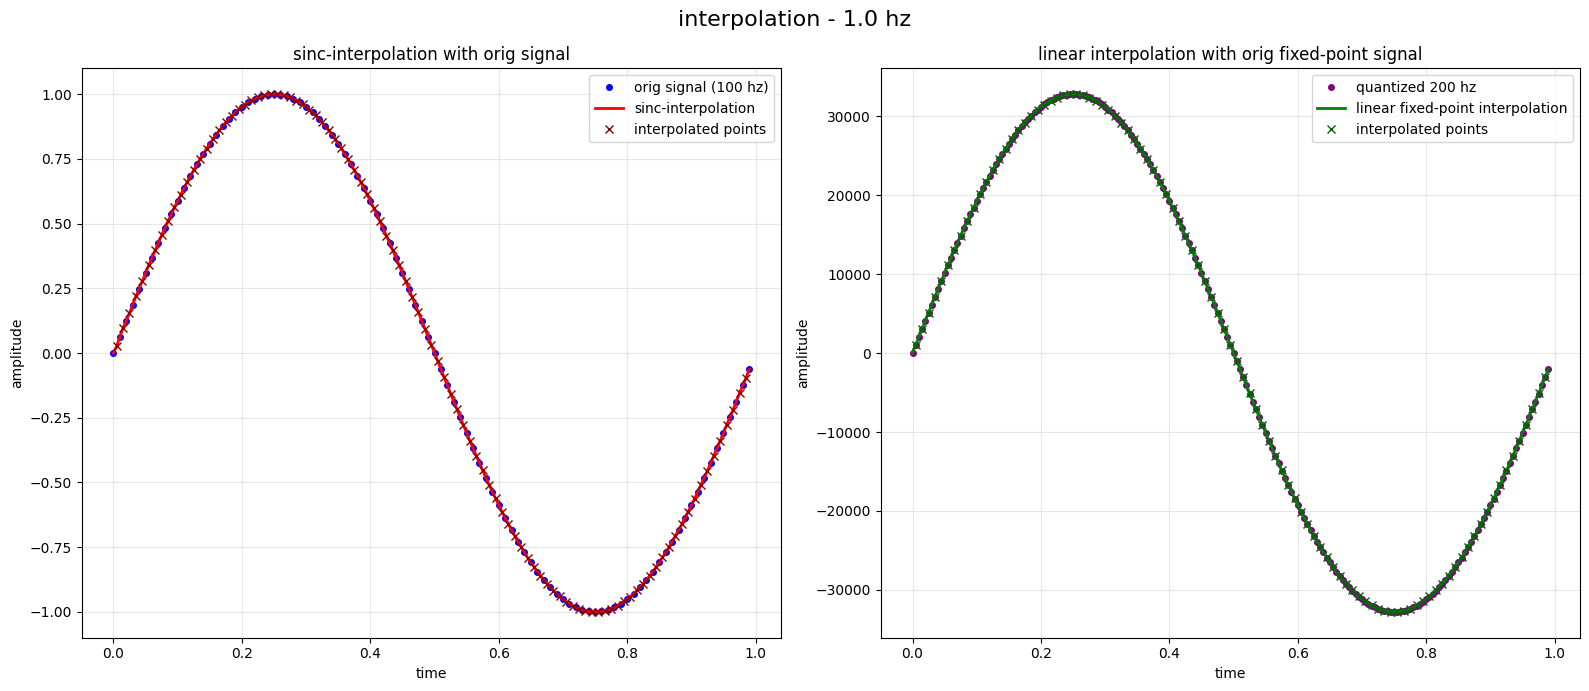

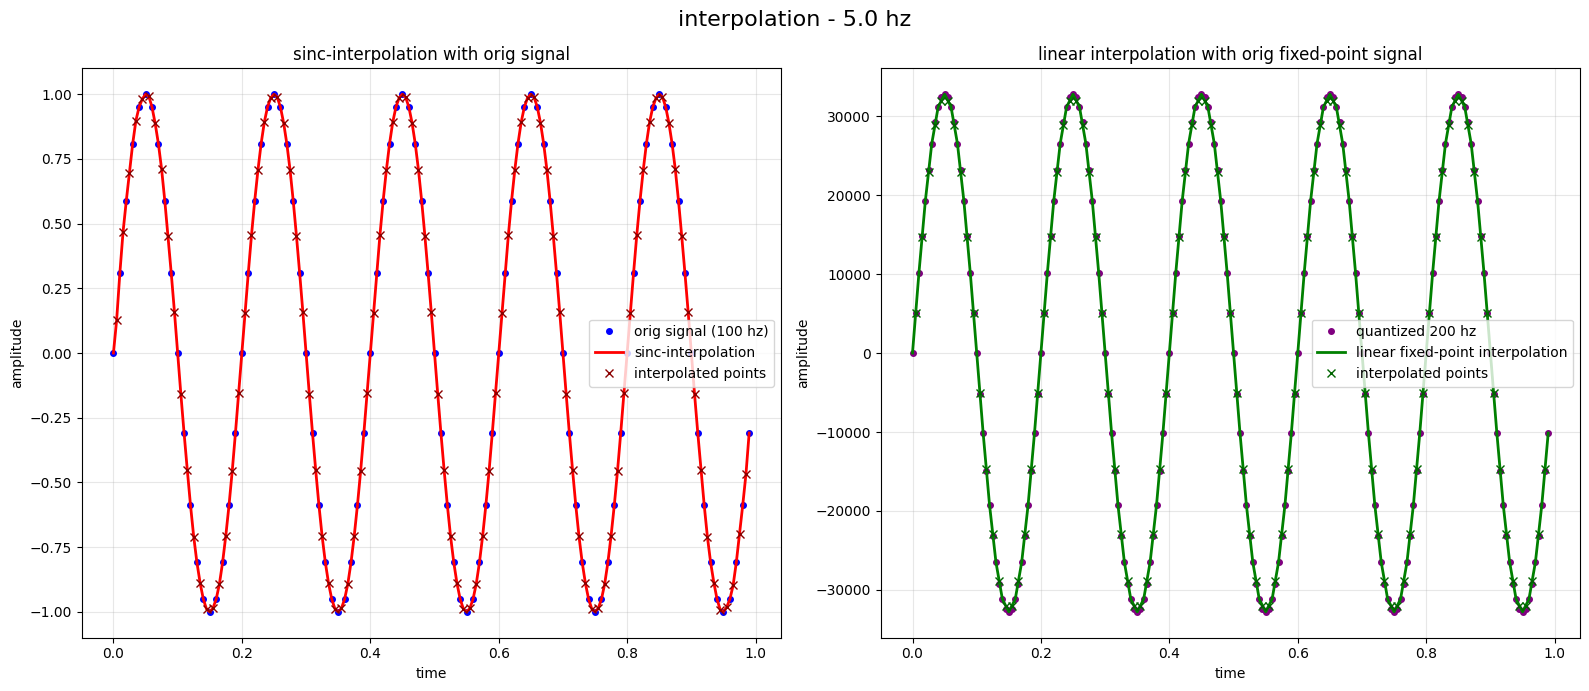

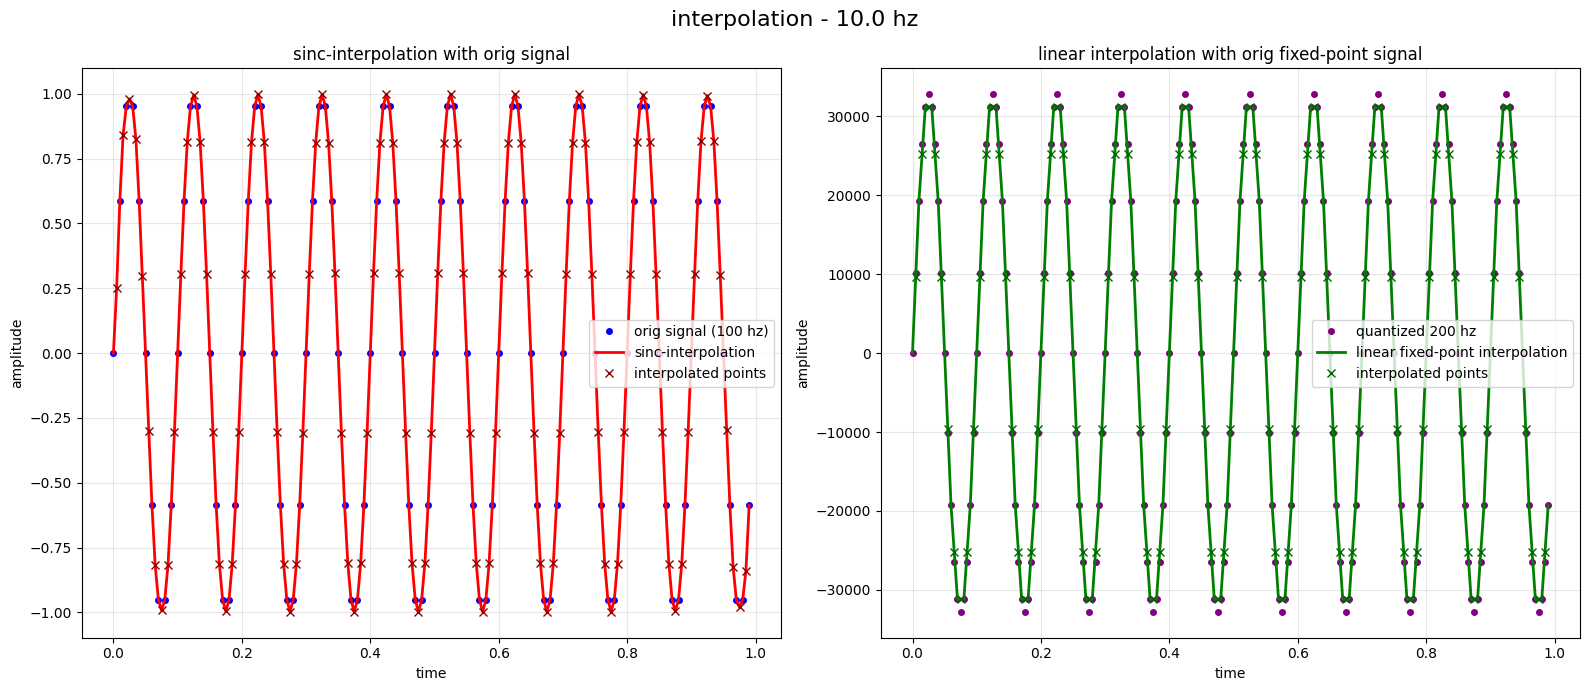

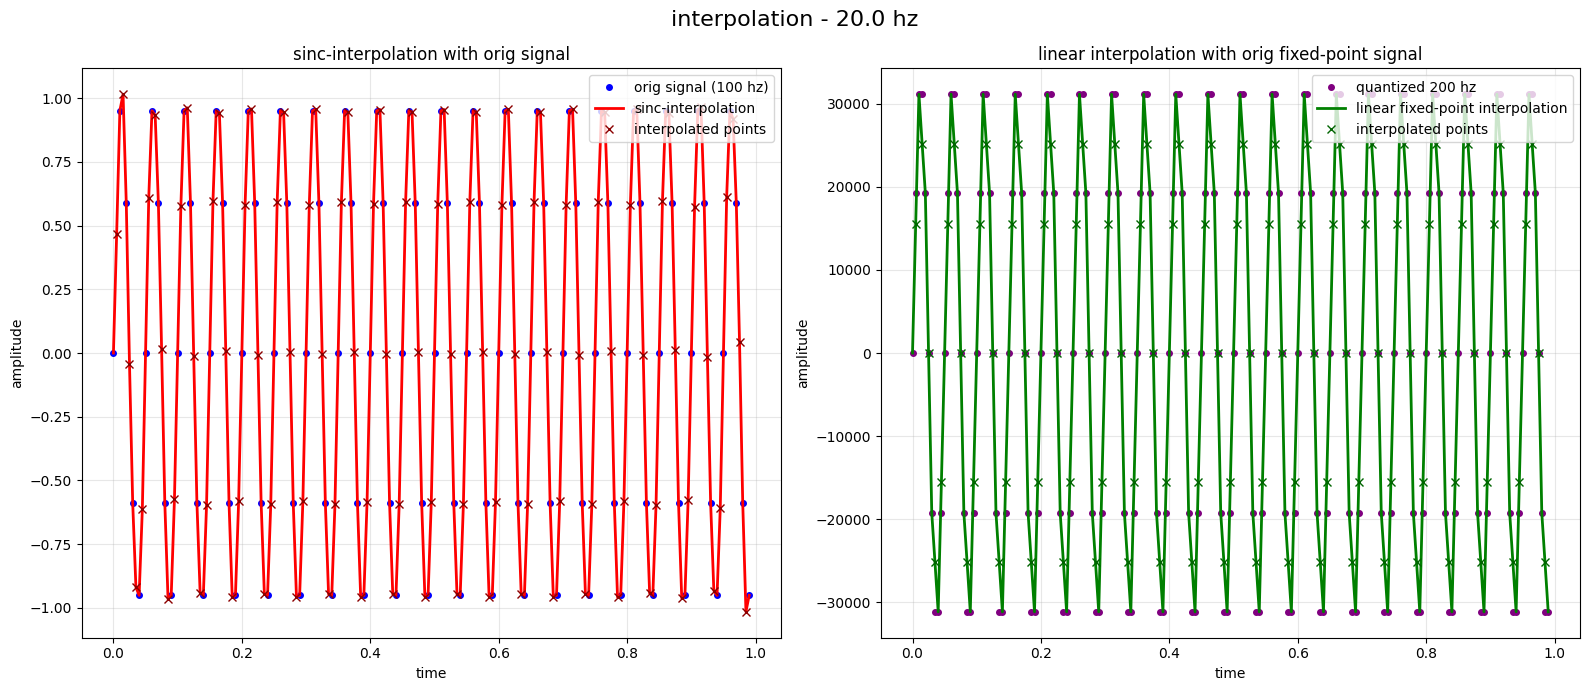

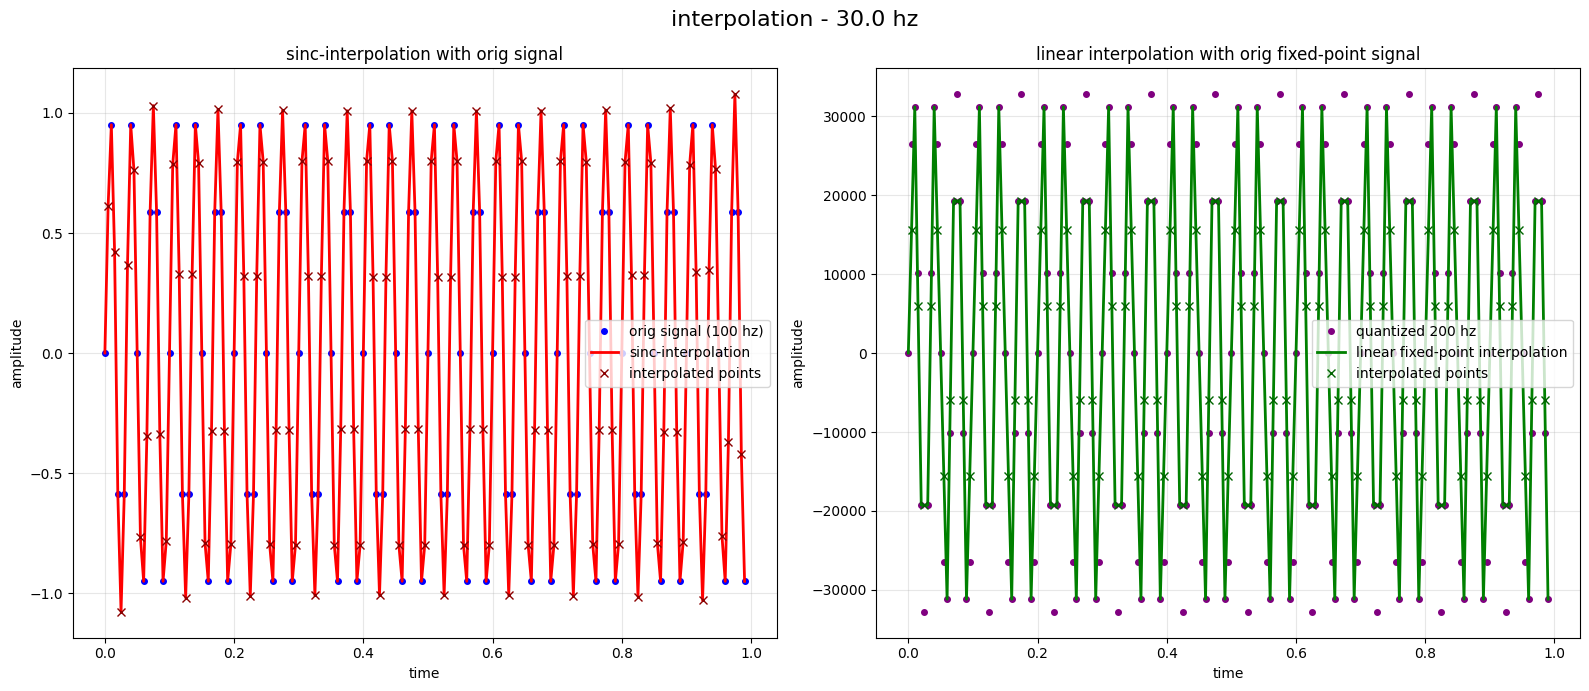

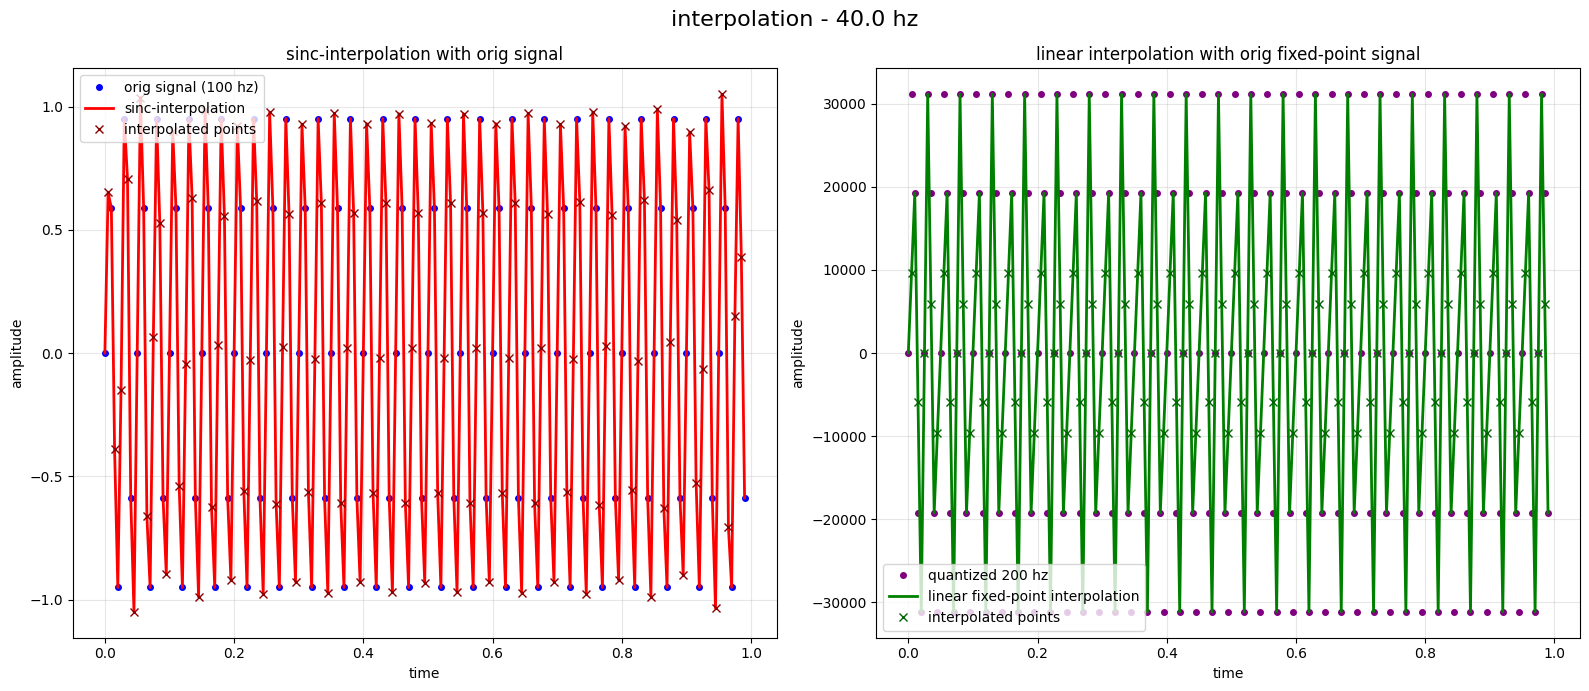

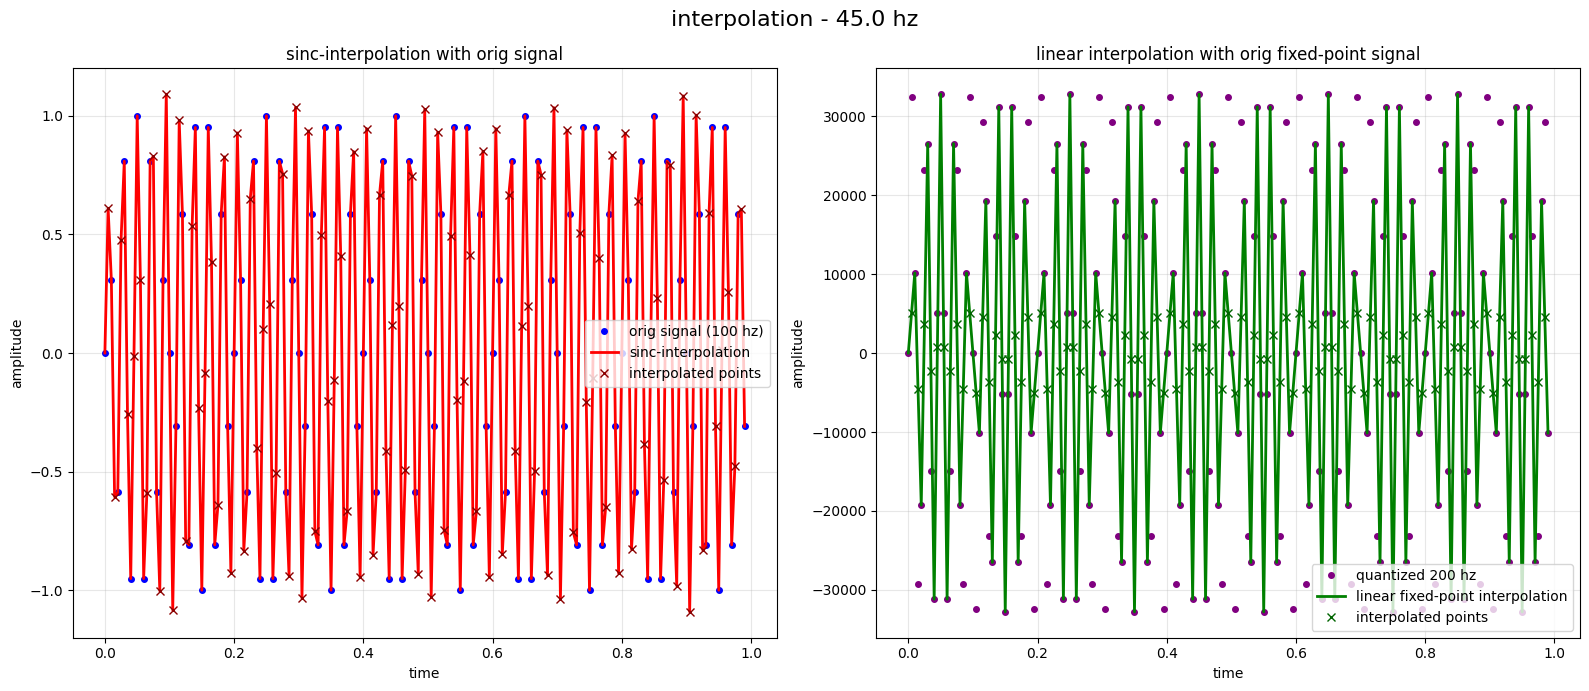

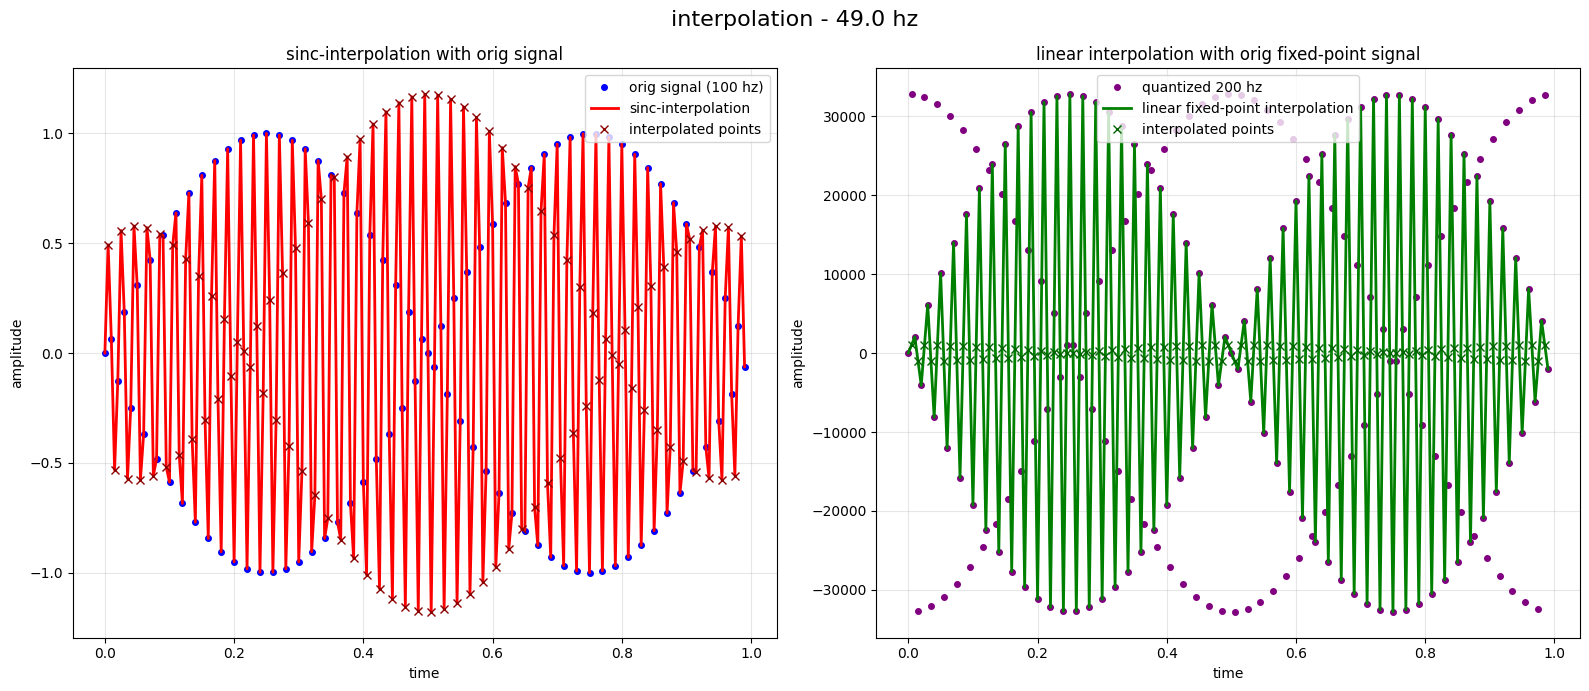

In [5]:
compare_interpolation()